# Implement Workflow Routing With OpenAI Agents and LangGraph

## Overview

You have been learning about **agentic design patterns**, which are architectural approaches for structuring workflows that help you build an AI agent system with reliable, accurate, and maintainable behavior.

In the previous project, you implemented **prompt chaining**, where the sequence of steps is fixed and known in advance. But what happens when the path depends on the input itself? That’s where another agentic design pattern &mdash; **routing** &mdash; comes in.

In this activity, you’ll implement a routing workflow using two approaches: OpenAI’s Agents SDK and LangGraph. You’ll begin by walking through a complete routing example implemented in both frameworks, then implement a similar routing workflow yourself using each approach.

## Routing

**What is Routing?**

Routing is an agentic design pattern used when building an AI agent system, where one agent uses an LLM to classify incoming input and direct it to the most appropriate specialized agent. Think of it like a receptionist at a large company: When you call in, they don't handle your request directly. Instead, they figure out what you need and transfer you to the right department.

Consider a customer support AI system. When a ticket comes in, the first step is classification: Is this a sales inquiry, a technical support issue, a refund request? Based on that classification, the ticket gets routed to a specialized agent that knows how to handle that specific type of request.


**Why Use LLM-Based Routing?**

Traditional routing relies on keyword matching or rigid rules. You might route any message containing "purchase" to the sales department and anything with "broken" or "not working" to the support desk. But language in the real world is messy and hard to predict. A customer might say "I bought this last week and now it won't turn on." Is that sales, because they mentioned buying, or support because something is broken? An LLM can understand the intent, not just the keywords.

Routing can also serve as a guardrail. Before processing a request, a classifier can check whether it's appropriate, malicious, or violates policy. Based on that assessment, it can route to an escalation pipeline or allow normal processing.

**When to Use Routing?**

Routing works well when:
- Your system handles multiple distinct types of requests
- Each type benefits from specialized handling (different prompts, tools, or models)
- The categories are relatively independent of each other
- You want to optimize cost by using simpler models for simpler tasks

Let's see this in action. 


### Initial Setup

Let's import the necessary libraries.

#### Run the Following Cell

In [1]:
# === Imports and Setup ===
from typing import Literal
from typing_extensions import TypedDict
from pydantic import BaseModel
from agents import Agent, Runner, set_tracing_disabled
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from IPython.display import Image, display, Markdown
set_tracing_disabled(True)

# === Initialize LLM ===
llm = ChatOpenAI(model="gpt-4.1")

## Routing With OpenAI Agents SDK

### Example: Implement Customer Support Ticket Router Workflow

Let's build a customer support routing system inspired by a real-world workflow.

**The scenario:** A tech company receives customer inquiries that need to be handled by different departments. The system should classify each ticket and route it to the appropriate specialized agent, which then drafts a response for human review.

**The Departments:**
- **Sales**: Handles inquiries about purchasing new products
- **Tech Support**: Handles troubleshooting for existing products
- **Returns/Refunds**: Handles return requests and refund processing
- **General**: Handles anything that doesn't fit the above categories (general questions, feedback, etc.)

Having a "general" category is important in real routing systems. Without it, you're forced to shoehorn ambiguous requests into categories where they don't belong. A customer asking "What are your business hours?" isn't a sales inquiry, a support issue, or a return request. The general agent handles these gracefully.

**The Architecture:**

```
                         ┌─→ [Sales Agent] ─────────┐
                         │                          │
                         ├─→ [Tech Support Agent] ──┤
Input → [Classifier] ────┤                          ├─→ Response Draft
                         ├─→ [Returns Agent] ───────┤
                         │                          │
                         └─→ [General Agent] ───────┘
```

Unlike prompt chaining where every input follows the same path, routing creates branching paths based on the classification result. 

In a routing workflow, the classifier agent examines the input, decides which category it belongs to, and the system routes to the appropriate specialized handler.

Let's implement this step by step.

### Step 1: Define the Classification Schema

The code cell below defines a Pydantic `BaseModel` named `TicketClassification` that defines the structure of the routing output. The classifier populates this schema, and the system uses its fields to determine which specialized agent to invoke.

There are two important things to notice about how the schema is defined.

* First, the system will use the `department` field to determine which specialized agent to invoke. We use a `Literal` type on the `department` field to constrain it to one of our four valid routing options (`"sales"`, `"tech_support"`, `"returns"`, `"general"`). This is crucial for two reasons:

    1. **Predictability**: By specifying exactly which values are allowed, we guarantee that the classifier's output will match one of our routing branches, ensuring that our routing logic always receives a valid, expected input. 

    2. **No invented categories**: Without constraints, the model might return values such as "Sales Department," "sales team," or "This is a sales inquiry," which would break routing logic that relies on exact string matches.

    Notice that we included `"general"` as an explicit category. This is a best practice in routing systems. Real-world inputs are messy, and some requests genuinely don't fit neatly into specialized categories. Having a catch-all prevents the classifier from forcing ambiguous requests into inappropriate categories. A question like "Do you have a physical store I can visit?" would awkwardly fit into sales, support, or returns, but it's a natural fit for general inquiries.

* Second, the `reasoning` field captures why the classifier made its decision. This is valuable for debugging and auditing. If a ticket is misrouted, you can check the reasoning to understand what went wrong.

#### Run the Following Cell

In [2]:
# === Classification Schema ===
class TicketClassification(BaseModel):
    """Output from the ticket classifier."""
    department: Literal["sales", "tech_support", "returns", "general"]  # Constrained to valid options
    reasoning: str  # Explanation of the classification decision

print("TicketClassification schema defined.")

TicketClassification schema defined.


### Step 2: Define the Agents

We now need to define five agents for our routing system:

1. **Classifier Agent**: Analyzes the ticket and determines which department should handle it. Notice how we set `output_type=TicketClassification` to ensure structured output that matches our schema.

2. **Sales Agent**: Drafts responses for purchase inquiries. Its instructions emphasize being helpful and enthusiastic about products.

3. **Tech Support Agent**: Drafts responses for troubleshooting issues. Its instructions focus on showing empathy and providing actionable steps.

4. **Returns Agent**: Drafts responses for return/refund requests. Its instructions emphasize being understanding and explaining the process clearly.

5. **General Agent**: Handles anything that doesn't fit the specialized categories. This is your safety net for ambiguous or miscellaneous requests.

Each specialized agent has focused instructions for its specific domain. This specialization is key to routing's value. A generic "handle everything" agent would need to juggle conflicting tones and approaches. By splitting into specialists, each agent can be optimized for its specific task.

#### Run the Following Cell

In [3]:
# === Classifier Agent ===
# Determines which department should handle the ticket
classifier_agent = Agent(
    name="Ticket Classifier",
    instructions="""You are a customer support ticket classifier for a tech company.
    
Analyze the customer's message and classify it into one of these departments:
- sales: Customer wants to purchase new products or asks about pricing/availability
- tech_support: Customer has issues with an existing product (troubleshooting, not working, etc.)
- returns: Customer wants to return a product or request a refund
- general: Anything else (general questions, feedback, business hours, store locations, etc.)

Return your classification with reasoning.""",
    model="gpt-4.1",
    output_type=TicketClassification
)

# === Sales Agent ===
# Handles purchase inquiries
sales_agent = Agent(
    name="Sales Agent",
    instructions="""You are a sales agent for a tech company. 
    
Draft a helpful, professional response to the customer's purchase inquiry. 
Be enthusiastic but not pushy. Offer to provide more information about products.
Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

# === Tech Support Agent ===
# Handles troubleshooting issues
tech_support_agent = Agent(
    name="Tech Support Agent",
    instructions="""You are a technical support agent for a tech company.
    
Draft a helpful response to the customer's technical issue.
Show empathy, then provide initial troubleshooting steps or ask clarifying questions.
Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

# === Returns Agent ===
# Handles return and refund requests
returns_agent = Agent(
    name="Returns Agent",
    instructions="""You are a returns and refunds agent for a tech company.
    
Draft a helpful response to the customer's return or refund request.
Be understanding and explain the next steps in the return process.
Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

# === General Agent ===
# Handles anything that doesn't fit other categories
general_agent = Agent(
    name="General Support Agent",
    instructions="""You are a general customer support agent for a tech company.
    
Draft a helpful response to the customer's inquiry. This might be a general question,
feedback, or something that doesn't fit into sales, technical support, or returns.
Be friendly and helpful. Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

print("All agents defined: Classifier, Sales, Tech Support, Returns, General")

All agents defined: Classifier, Sales, Tech Support, Returns, General


### Step 3: Build the Router Function

The router function orchestrates the classification and routing. Here's the flow:

1. **Classify**: Run the classifier agent to determine the department. The classifier analyzes the customer's message and returns a `TicketClassification` object with the department and reasoning.

2. **Display**: Show the classification result so we can see the routing decision. This transparency is valuable for debugging and helps users understand what the system is doing.

3. **Route**: Based on the classification, run the appropriate specialized agent. This is where the branching happens. Each department has its own agent with tailored instructions.

4. **Return**: Return the drafted response for human review.

The key insight is that the routing logic is just an `if`/`elif`/`else` statement. The classifier uses an LLM to handle the fuzzy, nuanced work of understanding what the customer wants. Once we have a structured classification, the routing becomes simple, deterministic code. This separation of concerns (LLM for understanding, code for control flow) is a powerful pattern you'll see throughout agentic systems.

#### Run the Following Cell

In [4]:
async def route_ticket(ticket: str) -> str:
    """
    Route a customer support ticket to the appropriate department.
    
    1. Classify the ticket using the classifier agent
    2. Route to the appropriate specialized agent based on classification
    3. Return the drafted response
    """
    
    # Step 1: Classify the ticket
    classifier_result = await Runner.run(classifier_agent, ticket)
    classification = classifier_result.final_output
    
    # Display the classification result
    output = f"""## Classification Result

**Department:** {classification.department}

**Reasoning:** {classification.reasoning}
"""
    display(Markdown(output))
    
    # Step 2: Route to the appropriate agent based on classification
    # Each branch explicitly handles one category
    if classification.department == "sales":
        result = await Runner.run(sales_agent, ticket)
        agent_name = "Sales Agent"
    elif classification.department == "tech_support":
        result = await Runner.run(tech_support_agent, ticket)
        agent_name = "Tech Support Agent"
    elif classification.department == "returns":
        result = await Runner.run(returns_agent, ticket)
        agent_name = "Returns Agent"
    else:  # general
        result = await Runner.run(general_agent, ticket)
        agent_name = "General Support Agent"
    
    # Step 3: Display and return the response
    response = result.final_output
    
    output = f"""## Response from {agent_name}

{response}
"""
    display(Markdown(output))
    
    return response

print("Router function defined: route_ticket()")

Router function defined: route_ticket()


### Step 4: Test the Router Workflow

Let's test with four different tickets, each designed to route to a different department:

1. **Ticket A**: A purchase inquiry &mdash; should route to Sales
2. **Ticket B**: A troubleshooting issue &mdash; should route to Tech Support
3. **Ticket C**: A return request &mdash; should route to Returns
5. **Ticket D**: A question about store hours

#### Run the Following Cell

In [5]:
# Test Ticket A: Purchase inquiry (should route to Sales)
ticket_a = "Hello, I would like to purchase a new laptop. What models do you have available?"

display(Markdown("# Test Ticket A: Purchase Inquiry\n\n**Customer Message:**\n> " + ticket_a))
response_a = await route_ticket(ticket_a)

# Test Ticket A: Purchase Inquiry

**Customer Message:**
> Hello, I would like to purchase a new laptop. What models do you have available?

## Classification Result

**Department:** sales

**Reasoning:** The customer is expressing interest in buying a new laptop and is inquiring about available models. This is clearly related to purchasing and product availability, which falls under the sales department.


## Response from Sales Agent

Thank you for your interest in our laptops! We offer a variety of models suitable for different needs, including high-performance, lightweight, and budget-friendly options. I’d be happy to provide more details or help you find the best fit—just let me know what you’re looking for!


#### Run the Following Cell

In [6]:
# Test Ticket B: Technical issue (should route to Tech Support)
ticket_b = "Hello, my laptop does not seem to be working. The screen stays black when I turn it on."

display(Markdown("# Test Ticket B: Technical Issue\n\n**Customer Message:**\n> " + ticket_b))
response_b = await route_ticket(ticket_b)

# Test Ticket B: Technical Issue

**Customer Message:**
> Hello, my laptop does not seem to be working. The screen stays black when I turn it on.

## Classification Result

**Department:** tech_support

**Reasoning:** The customer is describing an issue with their laptop (the screen remains black when powered on), which is a product malfunction or troubleshooting request. This should be classified under tech_support.


## Response from Tech Support Agent

I'm sorry you're experiencing this issue—it can be frustrating when your laptop won't start properly. Could you please let me know if you hear any sounds (like fans or startup chimes) or see any lights when turning it on? Also, try holding down the power button for 10 seconds, then release and press it again to see if the laptop responds.


#### Run the Following Cell

In [7]:
# Test Ticket C: Return request (should route to Returns)
ticket_c = "Hello, I would like to return my laptop. I purchased it last week but it doesn't meet my needs."

display(Markdown("# Test Ticket C: Return Request\n\n**Customer Message:**\n> " + ticket_c))
response_c = await route_ticket(ticket_c)

# Test Ticket C: Return Request

**Customer Message:**
> Hello, I would like to return my laptop. I purchased it last week but it doesn't meet my needs.

## Classification Result

**Department:** returns

**Reasoning:** The customer explicitly states that they would like to return their laptop, which they recently purchased. This is a clear request related to returns or refunds, making the 'returns' department the appropriate classification.


## Response from Returns Agent

Thank you for reaching out, and I’m sorry to hear the laptop isn’t the right fit. To start your return, please reply with your order number, and we’ll send you a prepaid shipping label along with instructions for returning the device. If you have any questions during the process, feel free to ask!


#### Run the Following Cell

In [14]:
# Test Ticket D: General request (should route to General Support)
ticket_d = "Hello, I would like to know more about store opening hours."

display(Markdown("# Test Ticket D: General Request\n\n**Customer Message:**\n> " + ticket_d))
response_d = await route_ticket(ticket_d)

# Test Ticket D: General Request

**Customer Message:**
> Hello, I would like to know more about store opening hours.

## Classification Result

**Department:** general

**Reasoning:** The customer's message is asking about store opening hours, which is a general inquiry and not related to sales, technical support, or returns.


## Response from General Support Agent

Thank you for reaching out! Our store opening hours vary by location, but most stores are open from 9 AM to 8 PM, Monday through Saturday. If you let me know your preferred location, I can provide the exact hours for that store.


### What Just Happened?

Let's break down the key aspects of this routing pattern:

**1. Structured Classification With Constrained Output**

The classifier returns a `TicketClassification` object with a constrained `department` field. Using `Literal["sales", "tech_support", "returns", "general"]` ensures the output is always one of our expected values. This is crucial because our routing logic depends on exact string matching. If the LLM returned "Sales Department" instead of "sales", our `if` statement would fail.

**2. Explicit Routing for Every Category**

Notice that we have an explicit branch for each category:
```python
if classification.department == "sales":
    result = await Runner.run(sales_agent, ticket)
elif classification.department == "tech_support":
    result = await Runner.run(tech_support_agent, ticket)
elif classification.department == "returns":
    result = await Runner.run(returns_agent, ticket)
else:  # general
    result = await Runner.run(general_agent, ticket)
```

The `else` clause handles `general`, which serves as our safety net. Even if something unexpected happens, we have a graceful fallback. This is much better than forcing an unrelated request into the returns category.

**3. Specialized Agents With Focused Instructions**

Each agent has instructions tailored to its domain:
- The **sales agent** is enthusiastic and helpful about products
- The **tech support agent** shows empathy and provides troubleshooting steps
- The **returns agent** is understanding and explains the process
- The **general agent** is friendly and adaptable

This specialization leads to better, more appropriate responses than a single generic agent trying to handle everything.

**4. The LLM Does the Hard Work**

The beauty of this pattern is the division of labor. The LLM handles the fuzzy, ambiguous task of understanding natural language intent. Your code handles the clean, predictable task of routing based on a structured classification. Each part does what it's best at.

### Why This Pattern Matters

Routing enables you to:
- **Specialize**: Each agent can be optimized for its specific task.
- **Scale**: Add new departments by adding new agents and classification options.
- **Optimize cost**: Use cheaper models for simpler classifications, more expensive models only where needed.
- **Debug**: When something goes wrong, you can check the classification reasoning to understand the issue.
- **Audit**: Every routing decision is logged with reasoning, creating a clear trail.

---

## Implement Your Own IT Helpdesk Router Workflow

Now it's your turn. You'll build a similar router workflow for an **IT Helpdesk** system.

**The scenario:** An IT department receives tickets from employees. Each ticket should be routed to the appropriate team based on the issue type.

**The Teams:**
- **Hardware**: Physical equipment issues (monitors, keyboards, laptops)
- **Software**: Application problems (crashes, installation, bugs)
- **Account Access**: Login issues, password resets, permission requests
- **General**: Anything else (questions about IT policies, feedback, general inquiries)

**Your Router:**
```
                          ┌─→ [Hardware Agent] ──────┐
                          │                          │
                          ├─→ [Software Agent] ──────┤
Input → [Classifier] ─────┤                          ├─→ Response
                          ├─→ [Account Agent] ───────┤
                          │                          │
                          └─→ [General Agent] ───────┘
```

There are two code cells below.

* In the first code cell, the classification schema and all agents have been defined for you.

* In the second code cell, your task is to complete the `route_helpdesk_ticket()` function by filling in the `if`/`elif`/`else` block with four calls to `await Runner.run()`. Use the classification result (e.g., the value of `classification.department`) to decide which specialized agent to invoke, and call `await Runner.run()` with that agent and the ticket as arguments.

#### Run the Following Cell

In [15]:
# === Classification Schema ===
class HelpdeskClassification(BaseModel):
    """Output from the IT helpdesk classifier."""
    department: Literal["hardware", "software", "account", "general"]  # Constrained to valid options
    reasoning: str  # Explanation of the classification decision


# === Classifier Agent ===
helpdesk_classifier = Agent(
    name="IT Helpdesk Classifier",
    instructions="""You are an IT helpdesk ticket classifier.
    
Analyze the employee's message and classify it into one of these teams:
- hardware: Physical equipment issues (monitors, keyboards, laptops, printers, cables)
- software: Application problems (crashes, installation, bugs, updates, licenses)
- account: Login issues, password resets, permission requests, access problems
- general: Anything else (IT policy questions, general inquiries, feedback)

Return your classification with reasoning.""",
    model="gpt-4.1",
    output_type=HelpdeskClassification
)

# === Hardware Agent ===
hardware_agent = Agent(
    name="Hardware Support",
    instructions="""You are an IT hardware support specialist.
    
Draft a helpful response for the hardware issue. Suggest basic checks 
(cables, power, connections) and offer to arrange a technician visit if needed.
Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

# === Software Agent ===
software_agent = Agent(
    name="Software Support",
    instructions="""You are an IT software support specialist.
    
Draft a helpful response for the software issue. Suggest common fixes 
(restart, update, reinstall) and offer to remote in if the issue persists.
Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

# === Account Agent ===
account_agent = Agent(
    name="Account Access Support",
    instructions="""You are an IT account access specialist.
    
Draft a helpful response for the account/access issue. Explain the process 
for password resets or permission requests, including any verification needed.
Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

# === General Agent ===
general_agent = Agent(
    name="General IT Support",
    instructions="""You are a general IT support specialist.
    
Draft a helpful response for general IT inquiries. This might be questions about
IT policies, general feedback, or requests that don't fit other categories.
Be friendly and helpful. Keep the response concise (2-3 sentences).""",
    model="gpt-4.1"
)

print("All agents defined: Helpdesk Classifier, Hardware, Software, Account Access, General")

All agents defined: Helpdesk Classifier, Hardware, Software, Account Access, General


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

In [16]:
async def route_helpdesk_ticket(ticket: str) -> str:
    """
    Route an IT helpdesk ticket to the appropriate team.
    """
    
    # Step 1: Classify the ticket
    classifier_result = await Runner.run(helpdesk_classifier, ticket)
    classification = classifier_result.final_output
    
    # Display the classification result
    output = f"""## Classification Result

**Department:** {classification.department}

**Reasoning:** {classification.reasoning}
"""
    display(Markdown(output))
    
    # Step 2: Route to the appropriate agent based on classification
    # Make Runner.run() calls with the correct agent and ticket
    if classification.department == "hardware":
        result = await Runner.run(hardware_agent, ticket)
        agent_name = "Hardware Support"
    elif classification.department == "software":
        result = await Runner.run(software_agent, ticket)
        agent_name = "Software Support"
    elif classification.department == "account":
        result = await Runner.run(account_agent, ticket)
        agent_name = "Account Access Support"
    else:  # general
        result = await Runner.run(general_agent, ticket)
        agent_name = "General IT Support"

   
    # Step 3: Display and return the response
    response = result.final_output
    
    output = f"""## Response from {agent_name}

{response}
"""
    display(Markdown(output))
    
    return response

print("Router function defined: route_helpdesk_ticket()")

Router function defined: route_helpdesk_ticket()


<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
Sample Solution:
<pre>
if classification.department == "hardware":
    result = await Runner.run(hardware_agent, ticket)
    agent_name = "Hardware Support"
elif classification.department == "software":
    result = await Runner.run(software_agent, ticket)
    agent_name = "Software Support"
elif classification.department == "account":
    result = await Runner.run(account_agent, ticket)
    agent_name = "Account Access Support"
else: 
    result = await Runner.run(general_agent, ticket)
    agent_name = "General IT Support"

</pre>
</p>

</details>

### Test Your Router Workflow

Run the cells below to test with four tickets:
1. **Ticket A**: Hardware issue &mdash; should route to Hardware
2. **Ticket B**: Account issue &mdash; should route to Account Access
3. **Ticket C**: Software issue &mdash; should route to Software
4. **Ticket D**: General inquiry &mdash; should route to General IT Support

#### Run the Following Cell

In [17]:
# Test Ticket A: Hardware issue
helpdesk_ticket_a = """My monitor keeps flickering and sometimes goes completely black. 
I've tried different cables but the problem persists."""

display(Markdown("# Test Ticket A: Hardware Issue\n\n**Employee Message:**\n> " + helpdesk_ticket_a))
helpdesk_response_a = await route_helpdesk_ticket(helpdesk_ticket_a)

# Test Ticket A: Hardware Issue

**Employee Message:**
> My monitor keeps flickering and sometimes goes completely black. 
I've tried different cables but the problem persists.

## Classification Result

**Department:** hardware

**Reasoning:** The user is experiencing issues with their monitor, including flickering and blacking out, and they have already tried changing cables without resolving the issue. This points to a possible hardware problem with the monitor itself rather than software or account issues.


## Response from Hardware Support

Thank you for trying different cables. Please also check that the monitor is securely connected to both power and your computer, and try plugging it into a different power outlet if possible. If the issue continues, I can arrange for a technician to visit and further diagnose the problem.


#### Run the Following Cell

In [18]:
# Test Ticket B: Account issue
helpdesk_ticket_b = """I forgot my password and now I'm locked out of my account. 
Can you help me reset it?"""

display(Markdown("# Test Ticket B: Account Issue\n\n**Employee Message:**\n> " + helpdesk_ticket_b))
helpdesk_response_b = await route_helpdesk_ticket(helpdesk_ticket_b)

# Test Ticket B: Account Issue

**Employee Message:**
> I forgot my password and now I'm locked out of my account. 
Can you help me reset it?

## Classification Result

**Department:** account

**Reasoning:** The employee is experiencing a login issue due to a forgotten password, resulting in being locked out of their account and requesting a password reset. This directly pertains to user account management.


## Response from Account Access Support

Absolutely, I can help you reset your password. Please visit the password reset page and follow the prompts—you’ll need to verify your identity, typically by entering your email and a code sent to you. If you have any issues or don’t receive the verification code, let me know for further assistance.


#### Run the Following Cell

In [19]:
# Test Ticket C: Software issue
helpdesk_ticket_c = """Excel keeps crashing whenever I try to open large spreadsheets. 
I've restarted my computer but it still happens."""

display(Markdown("# Test Ticket C: Software Issue\n\n**Employee Message:**\n> " + helpdesk_ticket_c))
helpdesk_response_c = await route_helpdesk_ticket(helpdesk_ticket_c)

# Test Ticket C: Software Issue

**Employee Message:**
> Excel keeps crashing whenever I try to open large spreadsheets. 
I've restarted my computer but it still happens.

## Classification Result

**Department:** software

**Reasoning:** The issue is with Excel, which is an application, crashing when opening large spreadsheets. The user's hardware appears to be functioning since the computer restarts correctly, and the issue is specific to the software. This fits the 'software' category as it involves application crashes.


## Response from Software Support

Thank you for letting me know. Please try updating Excel to the latest version and, if that doesn't help, try reinstalling the application. If the problem persists after these steps, let me know and I can remote in to assist further.


#### Run the Following Cell

In [20]:
# Test Ticket D: General inquiry
helpdesk_ticket_d = """What are the IT department's office hours? 
I'd like to drop by in person to pick up my new equipment."""

display(Markdown("# Test Ticket D: General Inquiry\n\n**Employee Message:**\n> " + helpdesk_ticket_d))
helpdesk_response_d = await route_helpdesk_ticket(helpdesk_ticket_d)

# Test Ticket D: General Inquiry

**Employee Message:**
> What are the IT department's office hours? 
I'd like to drop by in person to pick up my new equipment.

## Classification Result

**Department:** general

**Reasoning:** The employee is asking about the IT department's office hours, which is a general inquiry not related to hardware, software, or account-specific issues.


## Response from General IT Support

Our IT department is available for in-person visits Monday through Friday, from 9:00 AM to 5:00 PM. Feel free to stop by during these hours to pick up your new equipment—let us know if you need any assistance when you arrive!


---

## Routing With LangGraph

Now let's implement the same customer support routing workflow using **LangGraph**. This demonstrates that the routing pattern is framework-agnostic: the core concepts (classification, conditional branching, specialized handlers) remain the same regardless of which tool you use.

LangGraph implements routing through **conditional edges**:
- A **classifier node** analyzes the input and updates the state with a classification
- A **routing function** reads the classification and returns the name of the next node
- **Conditional edges** use the routing function to direct flow to the appropriate handler

The main conceptual difference from the Open AI Agents SDK is how the branching logic is expressed. In the SDK, routing is implemented using `if`/`elif`/`else` statements. In LangGraph, the same branching behavior is declared as edges in a graph, and LangGraph executes the control flow based on the routing function’s output.

### Example: Implement Customer Support Router Workflow With LangGraph

We'll implement the same four-department routing workflow:

```
                         ┌─→ [Sales Node] ──────────┐
                         │                          │
                         ├─→ [Tech Support Node] ───┤
Input → [Classifier] ────┤                          ├─→ END
                         ├─→ [Returns Node] ────────┤
                         │                          │
                         └─→ [General Node] ────────┘
```

The key differences from the Agents SDK approach:
- Instead of `if`/`elif`/`else` in Python, we use **conditional edges** in the graph
- The routing function returns the **name** of the target node as a string
- LangGraph handles the actual branching based on that return value
- The graph visualization makes the routing structure immediately visible

Let's build this step by step.

### Step 1: Define the State

Our state needs to track everything that flows through the routing system. In this routing workflow, `RouterState` defines the structure of the shared graph state object that flows between nodes. Each node reads from and writes to this state, and routing decisions (such as which `department` node to execute) are based on its fields.

- **`ticket`**: The input customer message (set at the start)
- **`department`**: The classification result, constrained to our four valid options
- **`reasoning`**: Why the classifier made this decision (useful for debugging)
- **`response`**: The final drafted response (set by whichever specialized node runs)

Notice that we use `Literal` in the state definition itself. This documents what values are valid and helps catch errors early. The state acts as the contract between all nodes in the graph.

#### Run the Following Cell

In [21]:
# === Define the State ===
class RouterState(TypedDict):
    ticket: str                                                          # The customer's message
    department: Literal["sales", "tech_support", "returns", "general"]   # Classification result
    reasoning: str                                                       # Classification reasoning
    response: str                                                        # Final drafted response

print("RouterState defined.")

RouterState defined.


### Step 2: Define the Node Functions

We need five node functions plus a routing function:

1. **Classifier node**: Analyzes the ticket and sets `department` and `reasoning` in the state
2. **Sales node**: Drafts a response for sales inquiries
3. **Tech Support node**: Drafts a response for technical issues
4. **Returns node**: Drafts a response for return requests
5. **General node**: Drafts a response for anything else

We also need a **routing function** that reads the classification from the state and returns the name of the target node. This function is the key to conditional edges. It doesn't modify state; it just returns a string that tells LangGraph where to go next.

**Understanding the Routing Function:**

```python
def route_by_department(state: RouterState) -> str:
    return state["department"]  # Returns "sales", "tech_support", "returns", or "general"
```

This function is deceptively simple but crucial. It reads the `department` field that the classifier set and returns it as a string. LangGraph uses this return value to decide which edge to follow.

The key requirements:
1. The return value must **exactly match** one of the node names registered in the graph
2. The function only reads from state; it doesn't modify anything
3. Every possible return value must have a corresponding edge defined

Notice that the classifier node has a fallback: If the LLM returns something unexpected, we default to `"general"`. This ensures we always have a valid routing target.

#### Run the Following Cell

In [22]:
# === Classifier Node ===
def classifier_node(state: RouterState):
    """Classify the ticket into a department."""
    prompt = f"""You are a customer support ticket classifier for a tech company.

Analyze this customer message and classify it into one of these departments:
- sales: Customer wants to purchase new products or asks about pricing/availability
- tech_support: Customer has issues with an existing product (troubleshooting, not working)
- returns: Customer wants to return a product or request a refund
- general: Anything else (general questions, feedback, business hours, etc.)

Customer message: {state['ticket']}

Respond with ONLY the department name (sales, tech_support, returns, or general) on the first line,
then your reasoning on the second line."""
    
    response = llm.invoke(prompt)
    lines = response.content.strip().split('\n', 1)
    department = lines[0].strip().lower()
    reasoning = lines[1].strip() if len(lines) > 1 else "No reasoning provided"
    
    # Ensure department is valid, default to general if not recognized
    if department not in ["sales", "tech_support", "returns", "general"]:
        department = "general"
    
    return {"department": department, "reasoning": reasoning}


# === Routing Function ===
def route_by_department(state: RouterState) -> str:
    """Return the name of the node to route to based on department."""
    return state["department"]  # Returns "sales", "tech_support", "returns", or "general"


# === Sales Node ===
def sales_node(state: RouterState):
    """Draft a response for sales inquiries."""
    prompt = f"""You are a sales agent for a tech company.

Draft a helpful, professional response to this purchase inquiry.
Be enthusiastic but not pushy. Keep it to 2-3 sentences.

Customer message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


# === Tech Support Node ===
def tech_support_node(state: RouterState):
    """Draft a response for technical issues."""
    prompt = f"""You are a technical support agent for a tech company.

Draft a helpful response showing empathy and providing initial troubleshooting steps.
Keep it to 2-3 sentences.

Customer message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


# === Returns Node ===
def returns_node(state: RouterState):
    """Draft a response for return/refund requests."""
    prompt = f"""You are a returns and refunds agent for a tech company.

Draft a helpful response explaining the return process.
Be understanding. Keep it to 2-3 sentences.

Customer message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


# === General Node ===
def general_node(state: RouterState):
    """Draft a response for general inquiries."""
    prompt = f"""You are a general customer support agent for a tech company.

Draft a helpful response to this general inquiry.
Be friendly and helpful. Keep it to 2-3 sentences.

Customer message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


print("All node functions defined: classifier_node, sales_node, tech_support_node, returns_node, general_node, route_by_department")

All node functions defined: classifier_node, sales_node, tech_support_node, returns_node, general_node, route_by_department


### Step 3: Build and Compile the Graph

Now we connect the nodes with edges. The key is the **conditional edge** after the classifier:

```python
workflow.add_conditional_edges(
    "classifier",           # From this node...
    route_by_department,    # ...call this function to decide...
    {                       # ...mapping return values to target nodes
        "sales": "sales",
        "tech_support": "tech_support",
        "returns": "returns",
        "general": "general"
    }
)
```

This says: "After the classifier runs, call `route_by_department(state)`. If it returns `'sales'`, go to the `sales` node. If it returns `'tech_support'`, go to the `tech_support` node." And so on for each category.

The mapping dictionary (`{"sales": "sales", ...}`) might look redundant, but it's actually powerful. The keys are what the routing function returns; the values are the node names. They happen to match here, but you could map `"purchase"` to `"sales"` if your routing function used different terminology.

#### Run the Following Cell

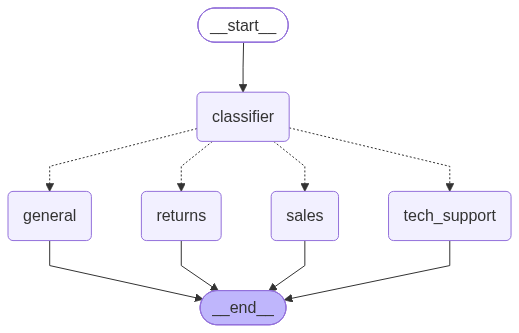

LangGraph router compiled successfully.


In [23]:
# === Build the Graph ===
workflow = StateGraph(RouterState)

# Add nodes
workflow.add_node("classifier", classifier_node)
workflow.add_node("sales", sales_node)
workflow.add_node("tech_support", tech_support_node)
workflow.add_node("returns", returns_node)
workflow.add_node("general", general_node)

# Add edges
workflow.add_edge(START, "classifier")  # Start with classification

# Conditional routing based on classification
workflow.add_conditional_edges(
    "classifier",
    route_by_department,
    {
        "sales": "sales",
        "tech_support": "tech_support",
        "returns": "returns",
        "general": "general"
    }
)

# All specialized nodes lead to END
workflow.add_edge("sales", END)
workflow.add_edge("tech_support", END)
workflow.add_edge("returns", END)
workflow.add_edge("general", END)

# Compile the graph
support_router = workflow.compile()

# Display the graph structure
display(Image(support_router.get_graph().draw_mermaid_png()))
print("LangGraph router compiled successfully.")

**Understanding the Graph Visualization:**

The diagram shows the routing structure:

```
START → classifier → (conditional) → sales ────────→ END
                                   → tech_support → END
                                   → returns ─────→ END
                                   → general ─────→ END
```

Notice a few things:
- All four specialized nodes converge on `END`. Each ticket takes exactly one path through the graph.
- The conditional edge from `classifier` branches to four possible destinations
- There's no "default" path in the graph itself. The routing function determines which branch to take, and every possible return value has a mapped destination.

This visual representation is one of LangGraph's strengths. You can immediately see the structure of your workflow, which makes debugging and explaining the system much easier.

### Step 4: Test the Router Workflow

Let's test with four tickets, each designed to route to a different department:

1. **Ticket A**: A purchase inquiry &mdash; should route to Sales
2. **Ticket B**: A troubleshooting issue &mdash; should route to Tech Support
3. **Ticket C**: A return request &mdash; should route to Returns
4. **Ticket D**: A general question &mdash; should route to General

#### Run the Following Cell

In [24]:
# Test Ticket A: Purchase inquiry (should route to Sales)
ticket_a = "Hello, I would like to purchase a new laptop. What models do you have available?"

display(Markdown("# Test Ticket A: Purchase Inquiry"))

result_a = support_router.invoke({"ticket": ticket_a})

output = f"""## Classification

**Department:** {result_a['department']}

**Reasoning:** {result_a['reasoning']}

## Response

{result_a['response']}
"""
display(Markdown(output))

# Test Ticket A: Purchase Inquiry

## Classification

**Department:** sales

**Reasoning:** The customer wants to purchase a new product and is asking about available models.

## Response

Thank you so much for reaching out! We offer a variety of laptops to fit different needs, including high-performance models, ultrabooks for portability, and budget-friendly options. I'd be happy to share more details or recommend the best option based on your preferences—just let me know what you’re looking for!


#### Run the Following Cell

In [25]:
# Test Ticket B: Technical issue (should route to Tech Support)
ticket_b = "Hello, my laptop does not seem to be working. The screen stays black when I turn it on."

display(Markdown("# Test Ticket B: Technical Issue"))

result_b = support_router.invoke({"ticket": ticket_b})

output = f"""## Classification

**Department:** {result_b['department']}

**Reasoning:** {result_b['reasoning']}

## Response

{result_b['response']}
"""
display(Markdown(output))

# Test Ticket B: Technical Issue

## Classification

**Department:** tech_support

**Reasoning:** The customer is experiencing an issue with their laptop not working and needs troubleshooting assistance.

## Response

I'm sorry to hear that your laptop screen is staying black—that can be really frustrating. Let's start by making sure it's properly charged and try holding the power button down for 10-15 seconds to perform a hard reset. If the issue persists, please let me know if you hear any sounds or see any lights when you try to power it on.


#### Run the Following Cell

In [26]:
# Test Ticket C: Return request (should route to Returns)
ticket_c = "Hello, I would like to return my laptop. I purchased it last week but it doesn't meet my needs."

display(Markdown("# Test Ticket C: Return Request"))

result_c = support_router.invoke({"ticket": ticket_c})

output = f"""## Classification

**Department:** {result_c['department']}

**Reasoning:** {result_c['reasoning']}

## Response

{result_c['response']}
"""
display(Markdown(output))

# Test Ticket C: Return Request

## Classification

**Department:** returns

**Reasoning:** The customer wants to return their laptop, which falls under the returns department.

## Response

Thank you for reaching out, and I’m sorry to hear the laptop isn’t the right fit for you. To start your return, please reply with your order number, and we’ll send you a prepaid shipping label along with simple instructions. If you have any questions during the process, we’re here to help!


#### Run the Following Cell

In [27]:
# Test Ticket D: General question (should route to General)
ticket_d = "Hello, I would like to know more about store opening hours."

display(Markdown("# Test Ticket D: General Question"))

result_d = support_router.invoke({"ticket": ticket_d})

output = f"""## Classification

**Department:** {result_d['department']}

**Reasoning:** {result_d['reasoning']}

## Response

{result_d['response']}
"""
display(Markdown(output))

# Test Ticket D: General Question

## Classification

**Department:** general

**Reasoning:** The customer is inquiring about store opening hours, which is a general question and not related to sales, technical support, or returns.

## Response

Hello! I’d be happy to help with that. Could you please let me know which store location you’re interested in, so I can provide you with the most accurate opening hours?


## Implement IT Helpdesk Router Workflow With LangGraph

Now you'll implement the same **IT Helpdesk** router workflow using LangGraph.

There are two code cells below.

* In the first code cell, the state and node functions have been defined for you. 

* In the second code cell, your task is to complete the graph-building step by registering the five nodes to the workflow.

    For each node, call `helpdesk_workflow.add_node()` with the following arguments:
    
    1. the node name (as a string)
    2. the function that implements that node

    **Hint:** Look at the conditional edges in the second code cell to see what node names are expected (`"classifier"`, `"hardware"`, `"software"`, `"account"`, `"general"`).


#### Run the Following Cell

In [28]:
# === IT Helpdesk State ===
class HelpdeskState(TypedDict):
    ticket: str
    department: Literal["hardware", "software", "account", "general"]
    reasoning: str
    response: str


# === Classifier Node ===
def helpdesk_classifier_node(state: HelpdeskState):
    """Classify the IT ticket into a team."""
    prompt = f"""You are an IT helpdesk ticket classifier.

Analyze this message and classify it into one of these teams:
- hardware: Physical equipment issues (monitors, keyboards, laptops, printers)
- software: Application problems (crashes, installation, bugs, updates)
- account: Login issues, password resets, permission requests
- general: Anything else (IT policy questions, general inquiries, feedback)

Message: {state['ticket']}

Respond with ONLY the team name (hardware, software, account, or general) on the first line,
then your reasoning on the second line."""
    
    response = llm.invoke(prompt)
    lines = response.content.strip().split('\n', 1)
    department = lines[0].strip().lower()
    reasoning = lines[1].strip() if len(lines) > 1 else "No reasoning provided"
    
    if department not in ["hardware", "software", "account", "general"]:
        department = "general"  # Default fallback
    
    return {"department": department, "reasoning": reasoning}


# === Routing Function ===
def helpdesk_route(state: HelpdeskState) -> str:
    """Return the name of the node to route to."""
    return state["department"]


# === Hardware Node ===
def helpdesk_hardware_node(state: HelpdeskState):
    """Draft response for hardware issues."""
    prompt = f"""You are IT hardware support. Draft a helpful response for this hardware issue.
Suggest basic checks and offer technician support. Keep it to 2-3 sentences.

Message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


# === Software Node ===
def helpdesk_software_node(state: HelpdeskState):
    """Draft response for software issues."""
    prompt = f"""You are IT software support. Draft a helpful response for this software issue.
Suggest common fixes and offer remote support. Keep it to 2-3 sentences.

Message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


# === Account Node ===
def helpdesk_account_node(state: HelpdeskState):
    """Draft response for account issues."""
    prompt = f"""You are IT account access support. Draft a helpful response for this access issue.
Explain the process and any verification needed. Keep it to 2-3 sentences.

Message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


# === General Node ===
def helpdesk_general_node(state: HelpdeskState):
    """Draft response for general IT inquiries."""
    prompt = f"""You are general IT support. Draft a helpful response for this general inquiry.
Be friendly and helpful. Keep it to 2-3 sentences.

Message: {state['ticket']}"""
    
    response = llm.invoke(prompt)
    return {"response": response.content}


print("All helpdesk nodes defined: classifier, hardware, software, account, general")

All helpdesk nodes defined: classifier, hardware, software, account, general


In the code cell below, replace the line `raise NotImplementedError("Your code is missing.")` with your code. As this is an ungraded notebook, your work will not be submitted for grading. 

#### Enter Your Solution Then Run the Following Cell

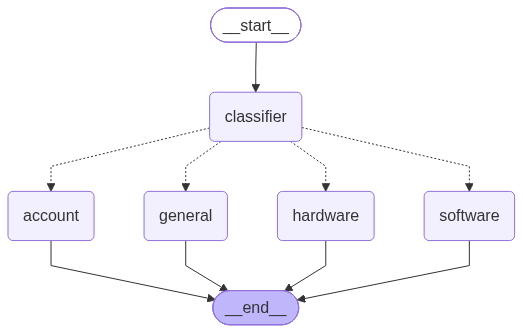

IT Helpdesk router compiled successfully.


In [31]:
# === Build the IT Helpdesk Router Graph ===

helpdesk_workflow = StateGraph(HelpdeskState)

# Add nodes - register each node function with a name
helpdesk_workflow.add_node("classifier", helpdesk_classifier_node)
helpdesk_workflow.add_node("hardware", helpdesk_hardware_node)
helpdesk_workflow.add_node("software", helpdesk_software_node)
helpdesk_workflow.add_node("account", helpdesk_account_node)
helpdesk_workflow.add_node("general", helpdesk_general_node)

# Add edges
helpdesk_workflow.add_edge(START, "classifier")

helpdesk_workflow.add_conditional_edges(
    "classifier",
    helpdesk_route,
    {
        "hardware": "hardware",
        "software": "software",
        "account": "account",
        "general": "general"
    }
)

helpdesk_workflow.add_edge("hardware", END)
helpdesk_workflow.add_edge("software", END)
helpdesk_workflow.add_edge("account", END)
helpdesk_workflow.add_edge("general", END)

# Compile
helpdesk_router = helpdesk_workflow.compile()

display(Image(helpdesk_router.get_graph().draw_mermaid_png()))
print("IT Helpdesk router compiled successfully.")

<details>
<summary style="text-align: left; background-color: #e3fbe3; color: #2a8bc6; padding: 10px 10px; cursor: pointer;" role="alert"><strong>✅ Solution</strong></summary>

<p style="padding: 10px;">
<pre>
helpdesk_workflow.add_node("classifier", helpdesk_classifier_node)
helpdesk_workflow.add_node("hardware", helpdesk_hardware_node)
helpdesk_workflow.add_node("software", helpdesk_software_node)
helpdesk_workflow.add_node("account", helpdesk_account_node)
helpdesk_workflow.add_node("general", helpdesk_general_node)
</pre>
</p>

</details>

### Test Your Router Workflow

Run the cells below to test with four IT helpdesk tickets:

1. **Ticket A**: Hardware issue &mdash; should route to Hardware
2. **Ticket B**: Account issue &mdash; should route to Account
3. **Ticket C**: Software issue &mdash; should route to Software
4. **Ticket D**: General inquiry &mdash; should route to General

#### Run the Following Cell

In [32]:
# Test Ticket A: Hardware issue
lg_ticket_a = """My monitor keeps flickering and sometimes goes completely black.
I've tried different cables but the problem persists."""

display(Markdown("# Test Ticket A: Hardware Issue"))

lg_result_a = helpdesk_router.invoke({"ticket": lg_ticket_a})

output = f"""## Classification

**Department:** {lg_result_a['department']}

**Reasoning:** {lg_result_a['reasoning']}

## Response

{lg_result_a['response']}
"""
display(Markdown(output))

# Test Ticket A: Hardware Issue

## Classification

**Department:** hardware

**Reasoning:** The issue is related to a physical component (the monitor) malfunctioning despite cable changes, which indicates a hardware problem.

## Response

Thank you for trying different cables—since the issue continues, please check that the monitor's power connection is secure and test the monitor with a different computer if possible. If the flickering and black screen still happen, we recommend a technician take a closer look to determine if the monitor or graphics hardware may be faulty. Let us know if you'd like to schedule a service appointment.


#### Run the Following Cell

In [33]:
# Test Ticket B: Account issue
lg_ticket_b = """I forgot my password and now I'm locked out of my account. 
Can you help me reset it?"""

display(Markdown("# Test Ticket B: Account Issue"))

lg_result_b = helpdesk_router.invoke({"ticket": lg_ticket_b})

output = f"""## Classification

**Department:** {lg_result_b['department']}

**Reasoning:** {lg_result_b['reasoning']}

## Response

{lg_result_b['response']}
"""
display(Markdown(output))

# Test Ticket B: Account Issue

## Classification

**Department:** account

**Reasoning:** The user is experiencing login issues and is requesting a password reset, which falls under account management.

## Response

I'm happy to help you reset your password. For security, I'll need to verify your identity—please provide your employee ID or answer your security questions via the secure link I'll send. Once verified, I'll guide you through the password reset process.


#### Run the Following Cell

In [34]:
# Test Ticket C: Software issue
lg_ticket_c = """Excel keeps crashing whenever I try to open large spreadsheets. 
I've restarted my computer but it still happens."""

display(Markdown("# Test Ticket C: Software Issue"))

lg_result_c = helpdesk_router.invoke({"ticket": lg_ticket_c})

output = f"""## Classification

**Department:** {lg_result_c['department']}

**Reasoning:** {lg_result_c['reasoning']}

## Response

{lg_result_c['response']}
"""
display(Markdown(output))

# Test Ticket C: Software Issue

## Classification

**Department:** software

**Reasoning:** The user is experiencing crashes with a specific application (Excel), which indicates a software issue.

## Response

I'm sorry to hear Excel keeps crashing. Please try updating Excel and disabling any add-ins (under File > Options > Add-ins). If the problem continues, I can assist you remotely—let me know if you'd like to set up a remote support session.


#### Run the Following Cell

In [35]:
# Test Ticket D: General inquiry
lg_ticket_d = """What are the IT department's office hours? 
I'd like to drop by in person to pick up my new equipment."""

display(Markdown("# Test Ticket D: General Inquiry"))

lg_result_d = helpdesk_router.invoke({"ticket": lg_ticket_d})

output = f"""## Classification

**Department:** {lg_result_d['department']}

**Reasoning:** {lg_result_d['reasoning']}

## Response

{lg_result_d['response']}
"""
display(Markdown(output))

# Test Ticket D: General Inquiry

## Classification

**Department:** general

**Reasoning:** The user is asking about the IT department's office hours, which is a general inquiry.

## Response

Thanks for reaching out! The IT department is open Monday through Friday from 8:30 AM to 5:00 PM. Feel free to stop by during those hours to pick up your new equipment—just let us know if you need any help when you arrive!


---

## Reflection: Routing

You've now implemented the **routing** pattern using two different frameworks. Take a moment to reflect on what you've learned.

### The Power of Classification

At its core, routing is really about classification. You take unstructured input (a customer message, an employee ticket, a user query) and map it to a structured category. Once you have that category, the routing itself is trivial. The LLM handles the hard part here.

Think about what this enables. In the past, building a ticket routing system meant writing hundreds of keyword rules, maintaining complex decision trees, and constantly updating logic as new edge cases appeared. Now, you describe the categories in plain English, and the LLM figures out the rest. When a new type of request appears, you add a category description rather than debugging regex patterns.

### The Importance of a Catch-All Category

We included a "general" category in both examples, and this is a deliberate design choice. Real-world inputs are messy. Some requests genuinely don't fit neatly into your specialized categories. Without a catch-all, you're forced to either:
1. Shoehorn requests into inappropriate categories; bad for users
2. Let the system fail on edge cases; bad for reliability

The general category gives you a graceful fallback. It's like having a "miscellaneous" folder. You hope most things get filed properly, but when something doesn't fit, you have somewhere sensible to put it.

### Routing vs. Prompt Chaining

In prompt chaining, every input follows the same path: step 1, then step 2, then step 3. The flow is deterministic and fixed. Routing introduces branching: The path depends on what the input actually is.

But here's the interesting part: Once the branch is chosen, you're often back to sequential processing within that branch. A sales inquiry might go through its own mini-chain (greeting, product info, call-to-action). A support ticket might go through a different chain (empathy, troubleshooting, escalation check). Routing and chaining aren't opposites; they're complementary patterns you can combine.

### The Constrained Output Trick

Notice how we used `Literal["sales", "tech_support", "returns", "general"]` to constrain the classification output. This is a small detail with big implications. Without constraints, the LLM might return "Sales Department," "sales," "SALES." or "This appears to be a sales inquiry." Your routing logic would need to handle all these variations.

By constraining the output, you guarantee that whatever comes back will match one of your expected branches. The LLM does the fuzzy understanding; your code handles clean, predictable values. This pattern of "fuzzy input, structured output" appears everywhere in agentic systems.

### When Should You Reach for Routing?

Routing shines when:
- You have distinct categories of requests that benefit from specialized handling
- The categories are relatively independent &mdash; a sales response doesn't need to know about support procedures
- You want to optimize resources &mdash; use cheaper models for simple categories, expensive models for complex ones
- You need an audit trail of how requests were classified

It's less ideal when:
- The classification itself requires deep reasoning or domain specific knowledge that cannot be provided to the agent as context
- Categories are highly interdependent

### Looking Ahead

Routing handles "which path should this take?" But what if you want to take multiple paths at once? That's where **parallelization** comes in, and it's what you'll explore in the next notebook.